# Post 05: How Should Pressure and Cell Degrees of Freedom Be Coupled?

This notebook is the presentation layer for the fifth tutorial. The reusable scalar-volume barostat diagnostics, compact reduced-unit argon cell-response check, and figure logic live in `src/kups_md_tutorials/`.

The goal is to separate ensemble fluctuation targets from barostat relaxation time, then connect those scalar checks to an atomistic pressure-volume sanity check: the same NPT target can have very different volume-memory behavior, and a real cell should show an interpretable pressure response when scaled.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.barostats import (
    expected_volume_variance,
    load_barostat_summary,
    simulate_scalar_barostat,
)
from kups_md_tutorials.config import load_barostat_spec
from kups_md_tutorials.figures import generate_post05_figures

## Configuration

The smoke and full profiles use a controlled scalar-volume model with known NPT-like volume and pressure fluctuation targets. The full profile compares fast, moderate, and slow relaxation times. Both profiles also include a deterministic reduced-unit FCC argon cell-response sweep, which scales the box affinely and evaluates the Lennard-Jones virial pressure.


In [3]:
smoke_spec = load_barostat_spec("05", "smoke")
full_spec = load_barostat_spec("05", "full")

for label in ["smoke", "full"]:
    config_path = Path(f"configs/post-05/{label}.json")
    print(f"--- {label} ---")
    print(json.dumps(json.loads(config_path.read_text()), indent=2))

--- smoke ---
{
  "post": "05",
  "profile": "smoke",
  "title": "How Should Pressure and Cell Degrees of Freedom Be Coupled?",
  "barostat_experiment": {
    "temperature": 1.0,
    "target_pressure": 1.0,
    "equilibrium_volume": 1000.0,
    "compressibility": 0.01,
    "time_step": 0.05,
    "num_steps": 3000,
    "warmup_steps": 500,
    "sample_every": 5,
    "seed": 2026071405,
    "barostats": [
      {
        "name": "fast_barostat",
        "relaxation_time": 0.5
      },
      {
        "name": "slow_barostat",
        "relaxation_time": 5.0
      }
    ]
  },
  "argon_cell_response": {
    "repetitions": 2,
    "number_density": 1.0,
    "temperature": 0.7,
    "volume_factors": [
      0.94,
      0.97,
      1.0,
      1.03,
      1.06
    ],
    "epsilon": 1.0,
    "sigma": 1.0,
    "cutoff": 2.5
  },
  "argon_npt_dynamics": {
    "repetitions": 2,
    "replica_count": 2,
    "number_density": 1.0,
    "target_pressure": 1.0,
    "temperature": 0.7,
    "compressibility

## Fluctuations Are The Signal

In an NPT ensemble, volume fluctuations are not noise to suppress. They encode compressibility. A useful barostat should recover the fluctuation scale while keeping memory and equilibration behavior interpretable.

In [4]:
exp = full_spec.experiment
print("expected volume variance", expected_volume_variance(exp.temperature, exp.compressibility, exp.equilibrium_volume))
case = full_spec.experiment.barostats[1]
times, volumes, pressures = simulate_scalar_barostat(
    temperature=exp.temperature,
    target_pressure=exp.target_pressure,
    equilibrium_volume=exp.equilibrium_volume,
    compressibility=exp.compressibility,
    time_step=exp.time_step,
    num_steps=100,
    warmup_steps=10,
    sample_every=5,
    relaxation_time=case.relaxation_time,
    seed=exp.seed,
)
list(zip(times[:5], volumes[:5], pressures[:5]))

expected volume variance 10.0


[(np.float64(0.5),
  np.float64(999.7534605854216),
  np.float64(1.0246539414578364)),
 (np.float64(0.75),
  np.float64(997.7114200500084),
  np.float64(1.2288579949991572)),
 (np.float64(1.0),
  np.float64(999.0146092886147),
  np.float64(1.098539071138532)),
 (np.float64(1.25),
  np.float64(998.8178399295479),
  np.float64(1.118216007045214)),
 (np.float64(1.5),
  np.float64(999.7624604798666),
  np.float64(1.0237539520133396))]

## Committed Outputs

The repository commits smoke and full summaries plus downsampled scalar volume/pressure samples. The summary records volume variance, pressure variance, volume autocorrelation diagnostics, and the compact argon pressure-volume response. The separate `argon_cell_response.csv` file keeps the atomistic cell sweep inspectable without mixing it into the scalar time-series samples.


In [5]:
result_dirs = {
    "smoke": Path("results/post-05/smoke"),
    "full": Path("results/post-05/full"),
}

for label, result_dir in result_dirs.items():
    print(f"--- {label} ---")
    for path in sorted(result_dir.iterdir()):
        print(f"{path}: {path.stat().st_size} bytes")

full_summary = load_barostat_summary(result_dirs["full"] / "barostat_summary.json")
argon = full_summary.argon_cell_response
if argon is not None:
    print(
        "argon cell response:",
        f"N={argon.atom_count}",
        f"Kfit={argon.fitted_bulk_modulus:.3f}",
        f"pressure_span={argon.pressure_span:.3f}",
    )
full_summary


--- smoke ---
results/post-05/smoke/argon_cell_response.csv: 330 bytes
results/post-05/smoke/argon_npt_dynamics.csv: 76972 bytes
results/post-05/smoke/barostat_samples.csv: 31110 bytes
results/post-05/smoke/barostat_summary.json: 4108 bytes
results/post-05/smoke/manifest.json: 2178 bytes
--- full ---
results/post-05/full/argon_cell_response.csv: 441 bytes
results/post-05/full/argon_npt_dynamics.csv: 114415 bytes
results/post-05/full/barostat_samples.csv: 55918 bytes
results/post-05/full/barostat_summary.json: 5323 bytes
results/post-05/full/manifest.json: 2300 bytes
argon cell response: N=108 Kfit=42.130 pressure_span=8.744


BarostatExperimentSummary(post='05', profile='full', temperature=1.0, target_pressure=1.0, equilibrium_volume=1000.0, compressibility=0.01, time_step=0.05, sample_every=10, seed=2026071405, config_sha256='281f7c7bab432bfff401be9b6c6e73d9a3731ccd974f61933e834f76c277ee13', runs=[BarostatRunSummary(barostat='fast_barostat', relaxation_time=0.5, samples=2500, volume_mean=999.6760317247359, volume_variance=9.787584469846385, expected_volume_mean=1000.0, expected_volume_variance=10.0, volume_variance_relative_error=-0.02124155301536157, pressure_mean=1.0323968275263973, pressure_variance=0.09787584469846385, expected_pressure_mean=1.0, expected_pressure_variance=0.1, pressure_variance_relative_error=-0.02124155301536157, volume_lag1_autocorrelation=0.33848275386135235, volume_integrated_autocorrelation_time=1.9908879238907913, volume_effective_samples=1255.7211131776073), BarostatRunSummary(barostat='moderate_barostat', relaxation_time=2.0, samples=2500, volume_mean=1000.0989697614353, volum

## Diagnostic Figure

The figure uses the full profile. It checks volume and pressure fluctuation targets, shows how the barostat relaxation time changes volume memory, and adds a reduced-unit argon pressure-volume panel from an actual affine cell scaling diagnostic.


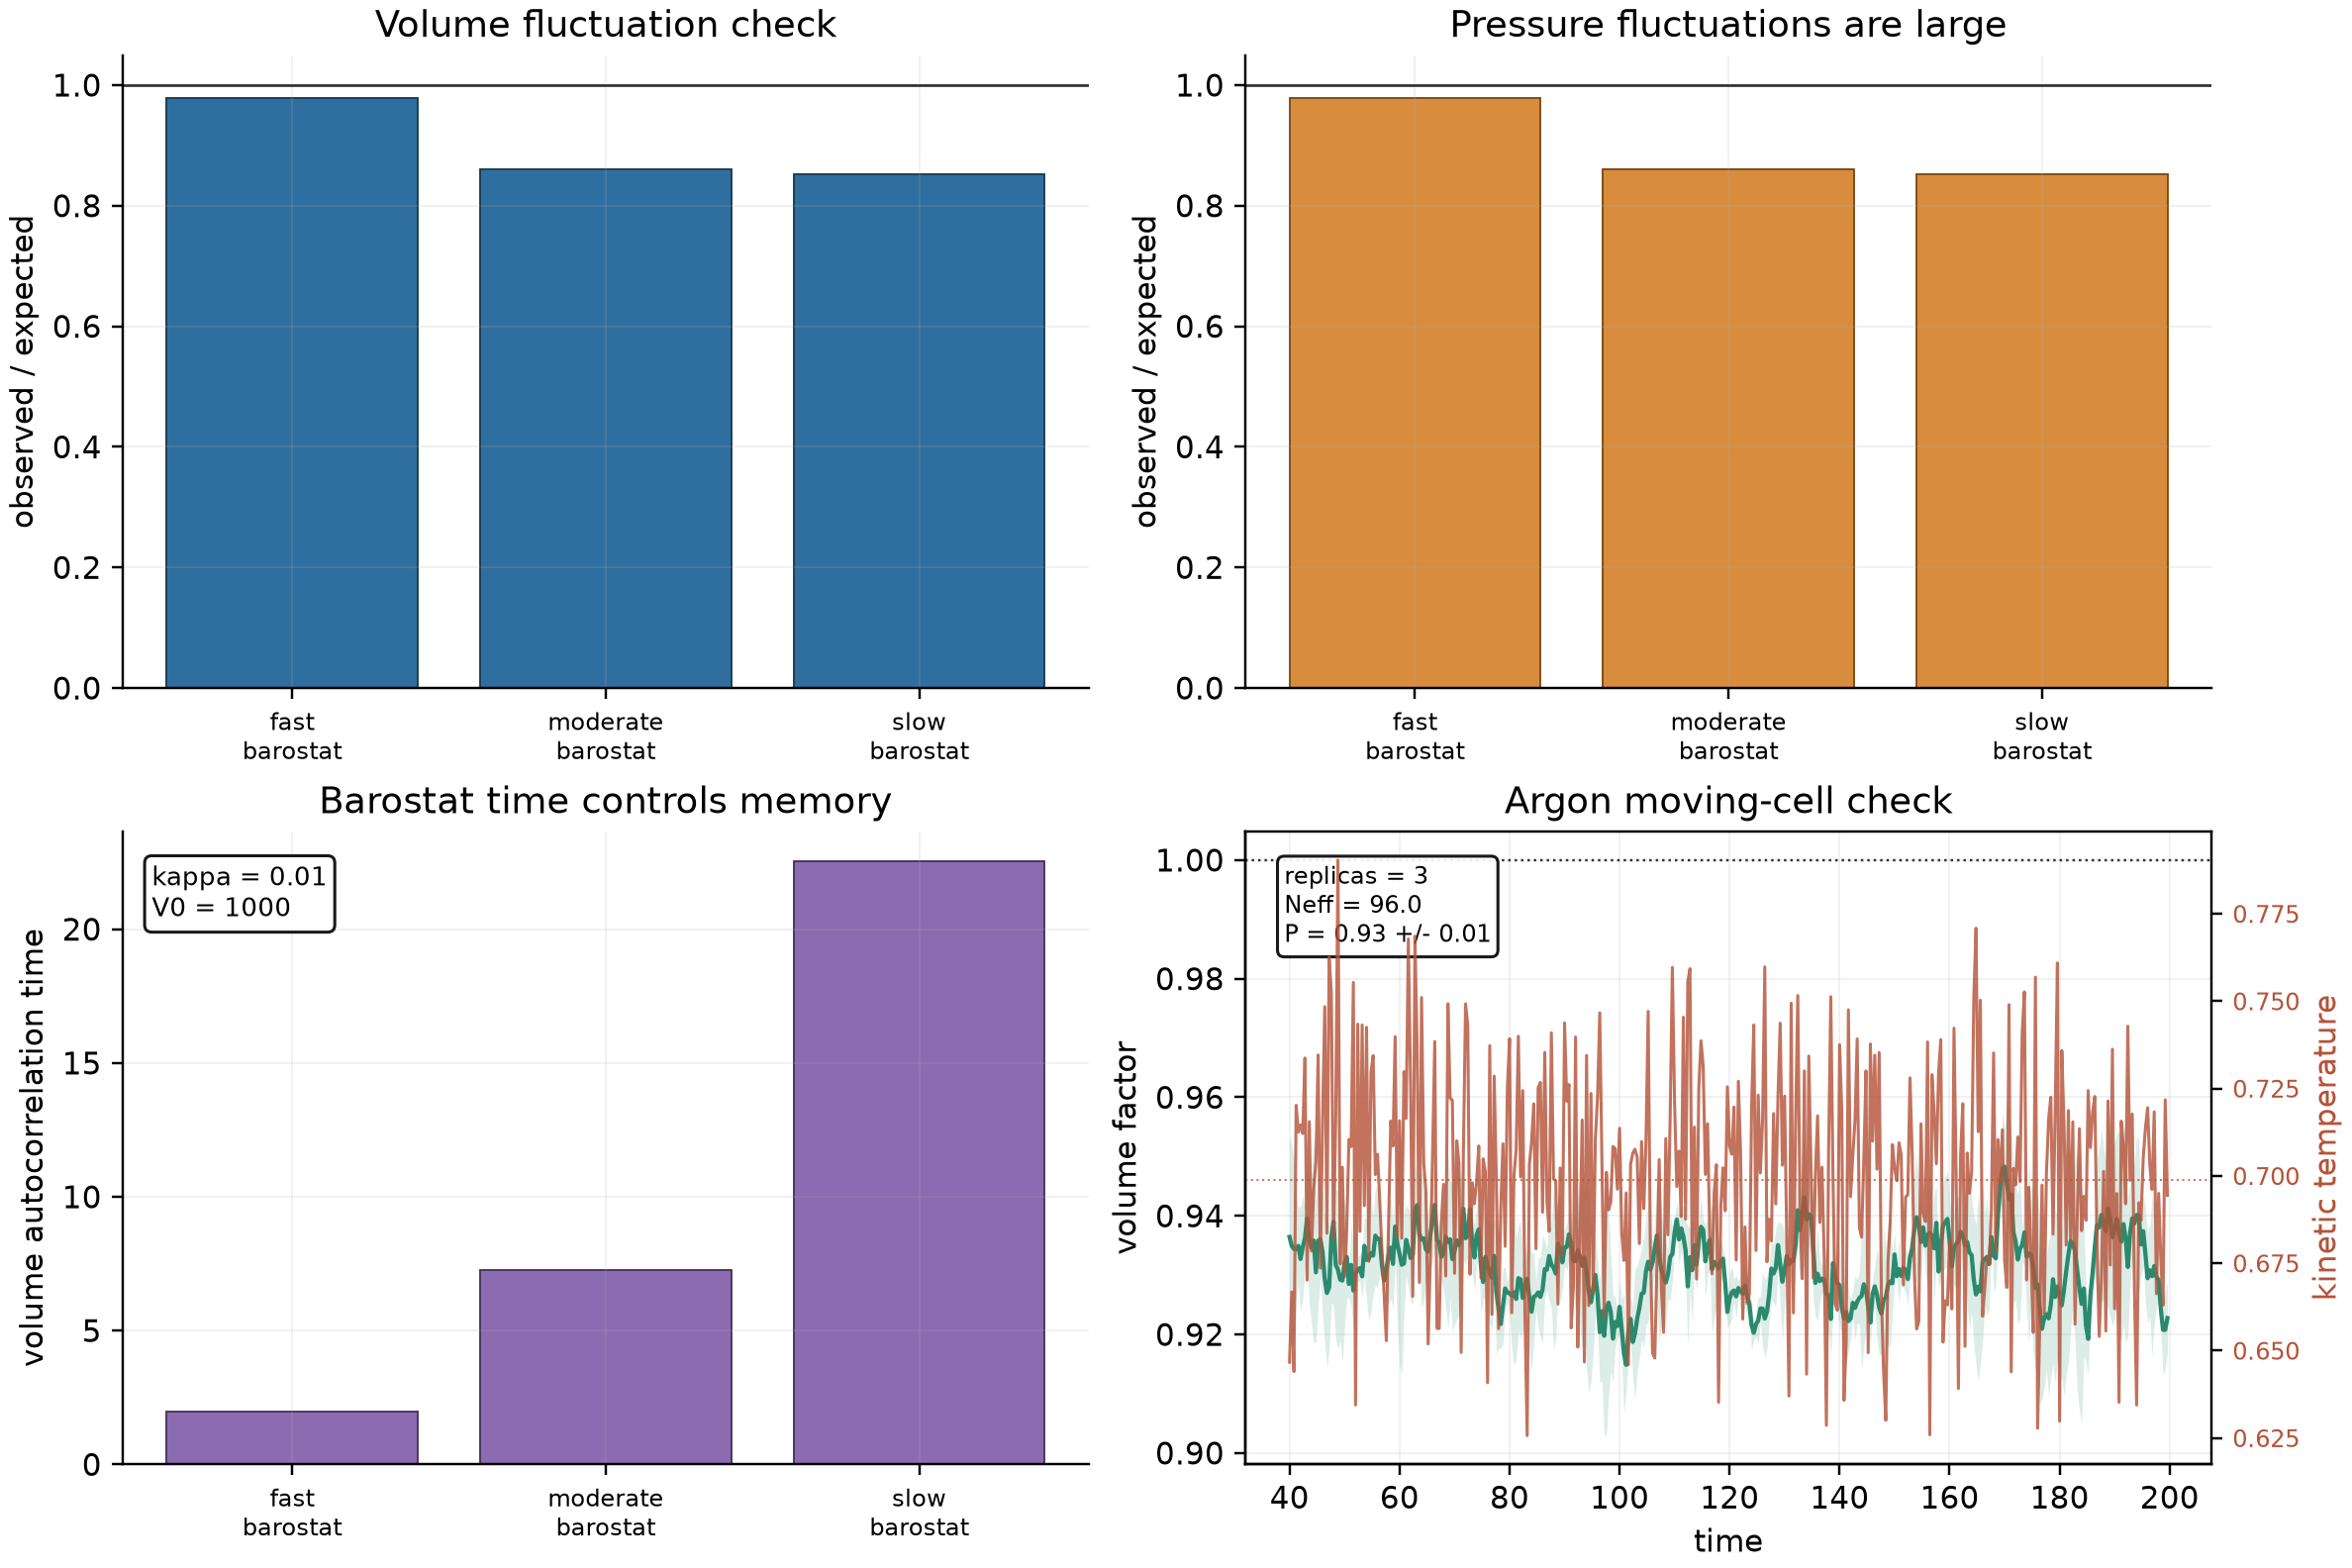

In [6]:
generate_post05_figures(
    result_dir=result_dirs["full"],
    figure_dir=Path("figures/post-05"),
    snapshot_dir=Path("snapshots/post-05"),
    name="barostat_diagnostics_full",
)
display(Image(filename="figures/post-05/barostat_diagnostics_full.png"))

## Takeaways

- Pressure fluctuates strongly in small systems; instantaneous pressure is not the observable.
- The volume variance is tied to compressibility and should not be tuned away.
- Barostat relaxation time changes equilibration and effective sample size.
- The compact argon cell-response check verifies that actual atomistic coordinates, box scaling, and virial pressure are wired into the post.
- A final production workflow still needs full argon/kUPS NPT dynamics with real cell degrees of freedom, not just static affine scaling.
